# 00. 微分積分の基礎 — 変化の速さと、蓄積された量の言語

> **この章の位置づけ**: 本書は「微分積分 → ODE → PDE → 応用」という流れで読む設計です。
> この 00 章は、その出発点となる **前提編** です。厳密な解析学を完全に展開するのが目的ではなく、
> 微分方程式を読むために必要な「直感の土台」を作ることが目的です。

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 6. 積分 |
| Applied | 7. 多変数微分 〜 9. Failure Mode |
| Advanced | 11. Advanced Notes |

## 1. Big Picture

微分積分の中心思想はこの一文に尽きます。

> **微分積分は、変化の「局所的な速さ」と、蓄積された「量」を扱うための言語である。**

- **微分** = ある瞬間に、量がどれくらいの速さで変わっているか(局所的な変化率)
- **積分** = その変化を足し合わせた結果、量がどれだけ蓄積したか(大域的な総和)

この 2 つは互いに逆向きの操作で、**微分積分学の基本定理** がそれらを結びつけます。
そして微分方程式とは、**「変化率そのものをルールとして与える」** 方程式です。
だからこそ、変化率(微分)と蓄積(積分)の言葉が話せないと、微分方程式は読めません。

## 2. Problem — 出発点となる問題

次の素朴な問いを、最後まで持ち歩いてください。

- **(A)** 走っている車の「いまの速さ」とは何か? 速度計は一瞬の値を指すが、
  速さは「距離 ÷ 時間」のはず。一瞬では時間も距離もゼロなのに、なぜ値が決まるのか?
- **(B)** デコボコに変化する量(気温・残高・人口)の「合計」や「平均」を、
  どうやって正確に足し合わせるのか?
- **(C)** 山の斜面に立ったとき、**最も急に登る方向** はどちらか? 何が決めているのか?

(A) は微分、(B) は積分、(C) は多変数微分(勾配)の問題です。

In [1]:
# Shared setup. Make the book package importable whether or not it is pip-installed,
# then fix the random seed and tidy NumPy printing.
import sys
from pathlib import Path

try:
    import ode_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "ode_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)

In [2]:
from ode_book import calculus, plotting

## 3. 関数 — 変化を入れる器

微分積分の主役は **関数** です。関数は「入力 $x$ を入れると出力 $f(x)$ が返ってくる装置」であり、
グラフとして描くと「入力と出力の対応の形」が一目で見えます。
代表的な関数(線形・二次・指数・対数・三角)の形を覚えておくと、後の議論が速くなります。

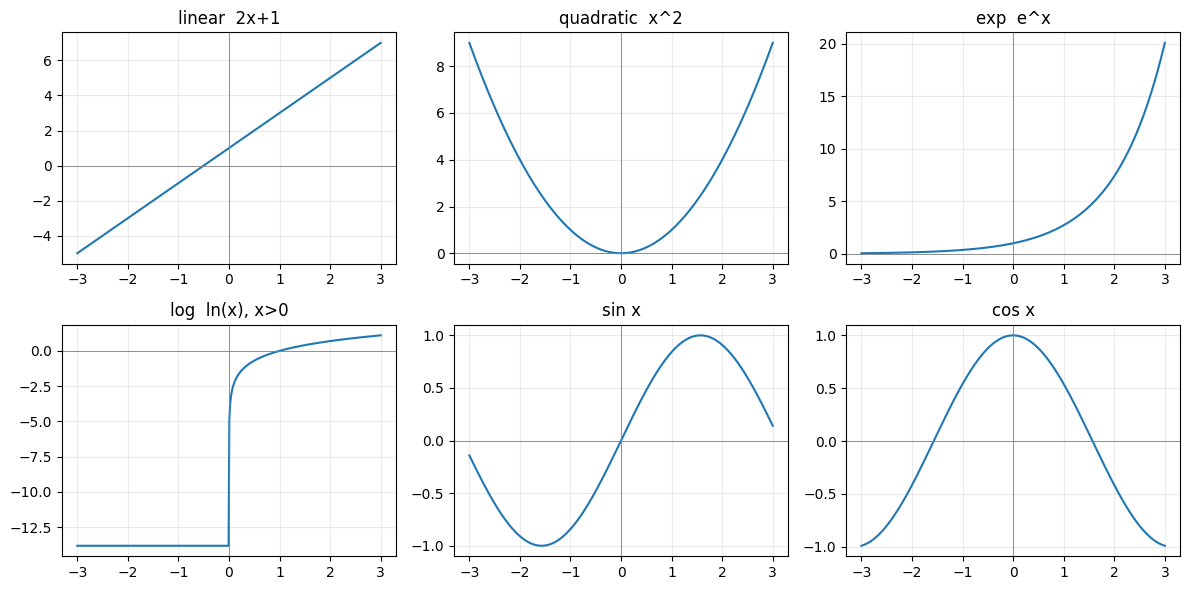

In [3]:
# The cast of elementary functions, seen as graphs.
xs = np.linspace(-3, 3, 400)
funcs = [
    ("linear  2x+1", lambda x: 2 * x + 1),
    ("quadratic  x^2", lambda x: x**2),
    ("exp  e^x", np.exp),
    ("log  ln(x), x>0", lambda x: np.log(np.clip(x, 1e-6, None))),
    ("sin x", np.sin),
    ("cos x", np.cos),
]
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, (name, fn) in zip(axes.ravel(), funcs):
    plotting.plot_function(fn, xs, ax=ax)
    ax.set_title(name)
fig.tight_layout()
plt.show()

## 4. 極限 — 「近づくとどうなるか」

問題 (A) の核心は **極限** です。平均変化率(差の商)

$$
\frac{f(x+h) - f(x)}{h}
$$

で $h$ をどんどん小さくしていくと、ある一つの値に近づきます。
その極限を **瞬間変化率** と呼びます。下のセルで、$\sin$ の $x=0$ での差の商が
$\cos(0) = 1$ に近づく様子を数値的に観察します。

In [4]:
# Watch the difference quotient of sin at x=0 settle onto cos(0)=1 as h -> 0.
for h in [1.0, 0.5, 0.1, 0.01, 1e-3, 1e-4]:
    print(f"h = {h:8.4f}   (f(x+h)-f(x))/h = {calculus.secant_slope(np.sin, 0.0, h):.6f}")

h =   1.0000   (f(x+h)-f(x))/h = 0.841471
h =   0.5000   (f(x+h)-f(x))/h = 0.958851
h =   0.1000   (f(x+h)-f(x))/h = 0.998334
h =   0.0100   (f(x+h)-f(x))/h = 0.999983
h =   0.0010   (f(x+h)-f(x))/h = 1.000000
h =   0.0001   (f(x+h)-f(x))/h = 1.000000


## 5. 微分 — 局所的な変化率

極限が定める瞬間変化率が **導関数** $f'(x)$ です。

$$
f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}
$$

図形的には、$f'(x)$ は **接線の傾き** です。下の図は、点を共有する **割線(secant)** の傾きが、
$h \to 0$ で **接線(tangent)** の傾きへ収束していく様子を示します。

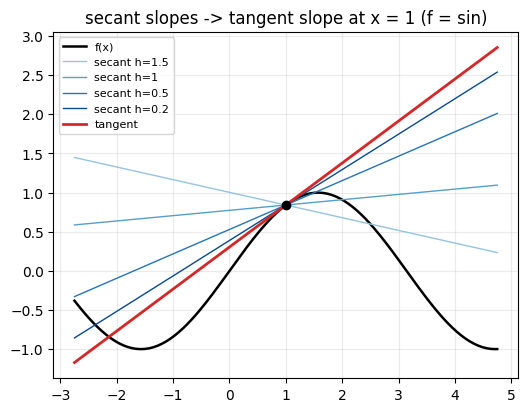

In [5]:
# Secant slopes through x0=1 collapse onto the tangent line as h shrinks.
ax = plotting.plot_secant_to_tangent(np.sin, x0=1.0, hs=[1.5, 1.0, 0.5, 0.2])
ax.set_title("secant slopes -> tangent slope at x = 1 (f = sin)")
plt.show()

**アニメーション**(Play で再生、静的 HTML でも動く):$h$ を小さくすると割線(赤)が接線(緑)へ近づきます。

In [6]:
import plotly.io as pio
from ode_book import interactive

pio.renderers.default = "plotly_mimetype+notebook_connected"
interactive.plotly_secant_to_tangent(np.sin, x0=1.0).show()

導関数そのものを「もとの関数の各点での傾き」として描くと、$f'$ が何を測っているのかが見えます。
数値微分(中心差分)と厳密な導関数を重ねて確認します。

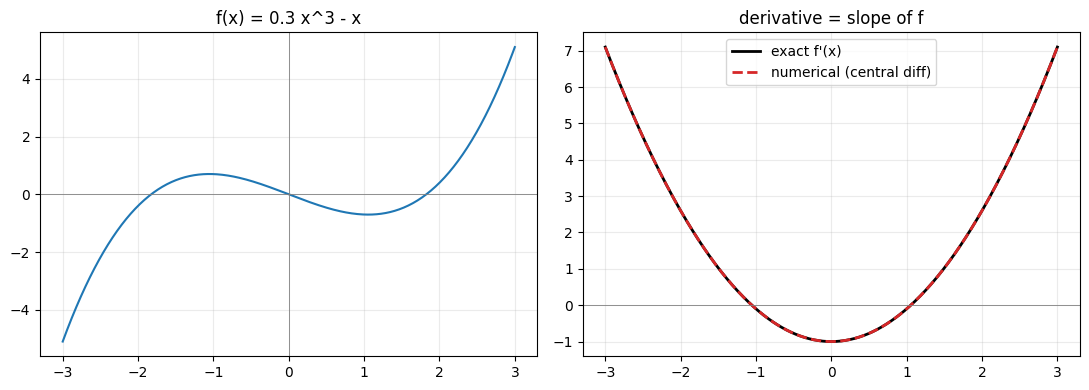

In [7]:
# The derivative function = slope of f at every point. Numerical vs exact.
xs = np.linspace(-3, 3, 400)
f = lambda x: 0.3 * x**3 - x          # f
df = lambda x: 0.9 * x**2 - 1         # exact f'
df_num = np.array([calculus.numerical_derivative(f, x) for x in xs])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
plotting.plot_function(f, xs, ax=a1)
a1.set_title("f(x) = 0.3 x^3 - x")
a2.plot(xs, df(xs), "k", lw=2, label="exact f'(x)")
a2.plot(xs, df_num, "--", color="#d62728", lw=2, label="numerical (central diff)")
a2.axhline(0, color="gray", lw=0.6)
a2.grid(alpha=0.25)
a2.legend()
a2.set_title("derivative = slope of f")
fig.tight_layout()
plt.show()

### 高階微分と Taylor 展開への入口

$f'$ をもう一度微分すると **二階微分** $f''$ で、これは「曲がり方(凹凸)」を測ります。
各点での微分を順に使うと、関数を多項式で近似する **Taylor 展開** が得られます。

$$
f(x) \approx f(a) + f'(a)(x-a) + \frac{f''(a)}{2!}(x-a)^2 + \cdots
$$

次数を上げるほど、近似は中心 $a$ の周りで広く一致していきます。

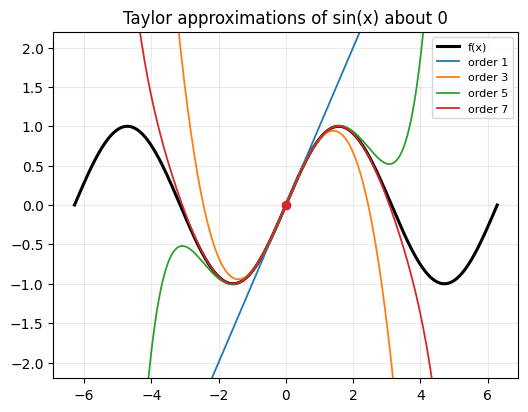

In [8]:
import sympy as sp

# Taylor approximations of sin around 0, orders 1,3,5,7.
x = sp.symbols("x")
approx = {k: calculus.taylor_approx(sp.sin(x), x, 0.0, k) for k in (1, 3, 5, 7)}
xs = np.linspace(-2 * np.pi, 2 * np.pi, 400)
ax = plotting.plot_taylor_approx(np.sin, approx, xs, x0=0.0)
ax.set_ylim(-2.2, 2.2)
ax.set_title("Taylor approximations of sin(x) about 0")
plt.show()

## 6. 積分 — 量の蓄積

問題 (B) に答えるのが **積分** です。区間 $[a,b]$ を細かく分け、各区間で
「高さ × 幅」の長方形を足し合わせたものが **Riemann 和** で、分割を細かくした極限が **定積分** です。

$$
\int_a^b f(x)\,dx = \lim_{n \to \infty} \sum_{i=1}^{n} f(x_i^\*)\,\Delta x
$$

幾何的には、これは **曲線の下の符号付き面積** です。分割数 $n$ を増やすと面積に収束します。

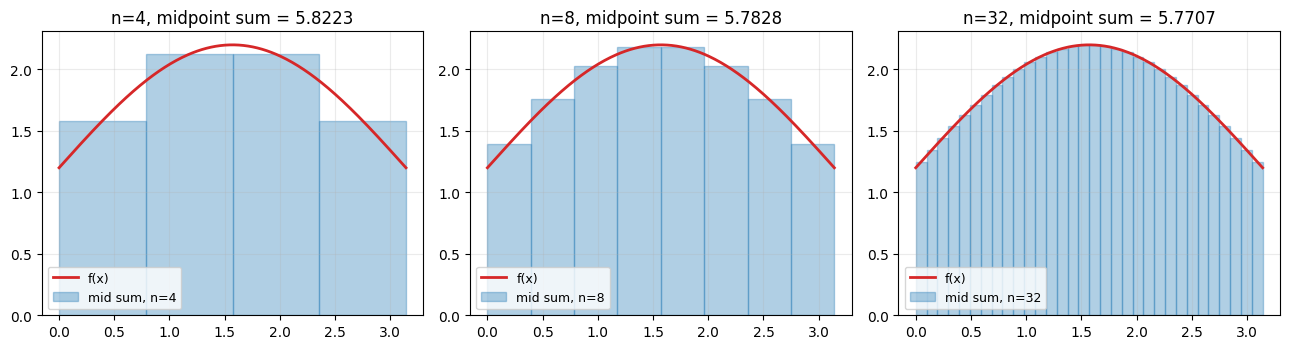

exact integral (adaptive quad) = 5.76991118430775


In [9]:
# Riemann rectangles converge to the area as n grows.
g = lambda x: np.sin(x) + 1.2
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, n in zip(axes, (4, 8, 32)):
    plotting.plot_riemann(g, 0, np.pi, n, rule="mid", ax=ax)
    ax.set_title(f"n={n}, midpoint sum = {calculus.riemann_sum(g, 0, np.pi, n, 'mid'):.4f}")
fig.tight_layout()
plt.show()
print("exact integral (adaptive quad) =", calculus.quad(g, 0, np.pi))

**アニメーション**(Play で再生):分割数 $n$ を増やすと、中点長方形の総和が真の面積へ収束していきます。

In [10]:
import plotly.io as pio
from ode_book import interactive

pio.renderers.default = "plotly_mimetype+notebook_connected"
interactive.plotly_riemann_convergence(lambda x: np.sin(x) + 1.2, 0, np.pi).show()

### 微分積分学の基本定理 (FTC)

積分は微分の逆操作です。上端を動かした積分

$$
F(x) = \int_a^x f(t)\,dt
\qquad\Longrightarrow\qquad
F'(x) = f(x)
$$

を **微分積分学の基本定理** と呼びます。「$f$ を積めば $F$、$F$ を微分すれば $f$ に戻る」という関係です。
$f = \cos$ で確認すると、積分 $F$ はちょうど $\sin$ になります。

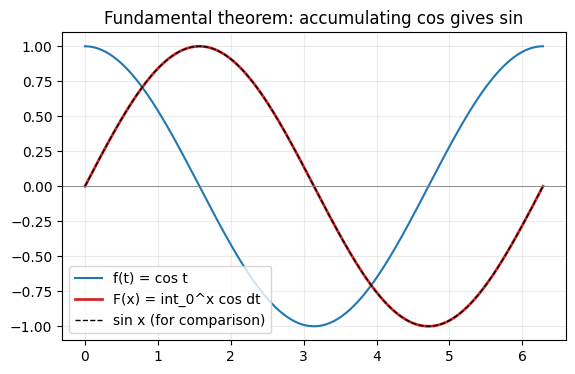

In [11]:
# FTC check: integrating cos from 0 reproduces sin.
xs = np.linspace(0, 2 * np.pi, 400)
F = calculus.cumulative_integral(np.cos, xs)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(xs, np.cos(xs), color="#1f77b4", label="f(t) = cos t")
ax.plot(xs, F, color="#d62728", lw=2, label="F(x) = int_0^x cos dt")
ax.plot(xs, np.sin(xs), "k--", lw=1, label="sin x (for comparison)")
ax.axhline(0, color="gray", lw=0.6)
ax.grid(alpha=0.25)
ax.legend()
ax.set_title("Fundamental theorem: accumulating cos gives sin")
plt.show()

## 7. 多変数微分 — 偏微分・勾配・Hessian (Applied)

入力が 2 つ以上ある関数 $f(x, y)$ では、「どの方向に動かすか」で変化率が変わります。

- **偏微分** $\partial f/\partial x$: 他を固定して $x$ だけ動かしたときの変化率
- **勾配** $\nabla f = (\partial f/\partial x,\ \partial f/\partial y)$: **最も急に増える方向** を指すベクトル(問題 (C) の答え)
- **方向微分**: 任意の単位方向 $\mathbf{u}$ に沿った変化率 $\nabla f \cdot \mathbf{u}$
- **Hessian** $H_f$: 二階偏微分を並べた行列で、曲面の **曲がり方** を表す

等高線図に勾配ベクトルを重ねると、勾配が必ず「等高線に直交し、高い方を向く」ことが見えます。

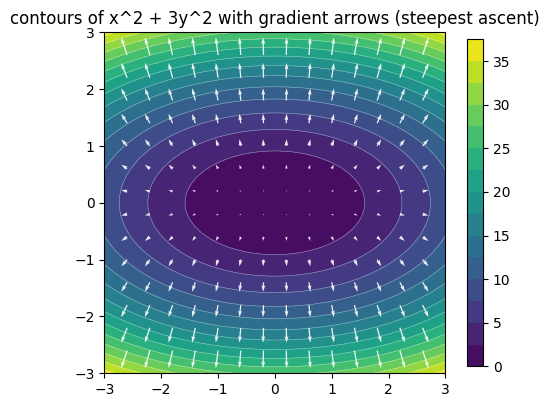

grad at (1, 1)      = [2. 6.]
d/du at (1,1), u=+x = 2.0000000000131024
Hessian at (1, 1)   =
 [[2. 0.]
 [0. 6.]]


In [12]:
# Gradient field over the contours of a bowl: arrows point uphill, normal to contours.
bowl = lambda p: p[0] ** 2 + 3 * p[1] ** 2
ax = plotting.contour_plot(bowl, (-3, 3), (-3, 3), with_gradient=True)
ax.set_title("contours of x^2 + 3y^2 with gradient arrows (steepest ascent)")
plt.show()

print("grad at (1, 1)      =", calculus.gradient(bowl, [1.0, 1.0]))   # (2, 6)
print("d/du at (1,1), u=+x =", calculus.directional_derivative(bowl, [1.0, 1.0], [1.0, 0.0]))
print("Hessian at (1, 1)   =\n", calculus.hessian(bowl, [1.0, 1.0]))

**二階微分は曲がり方** という直感を、鞍点 $f(x,y) = x^2 - y^2$ で確かめます。
Hessian の固有値は符号が混ざり(一方向は上に凸、別方向は下に凸)、これが「鞍(さどる)」の形です。

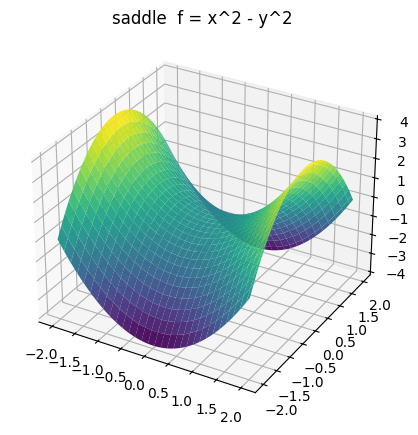

Hessian eigenvalues at origin: [ 2. -2.]


In [13]:
# Saddle: the Hessian has mixed-sign eigenvalues -> curvature up in one axis, down in the other.
saddle = lambda p: p[0] ** 2 - p[1] ** 2
ax = plotting.surface_plot(saddle, (-2, 2), (-2, 2))
ax.set_title("saddle  f = x^2 - y^2")
plt.show()
print("Hessian eigenvalues at origin:", np.linalg.eigvals(calculus.hessian(saddle, [0.0, 0.0])))

## 8. 多重積分 — 面積・体積・密度 (Applied)

積分は多変数にも拡がります。**二重積分**

$$
\iint_D f(x, y)\,dx\,dy
$$

は、$f \ge 0$ なら「底面 $D$ の上、曲面 $z=f(x,y)$ の下」の **体積** です。
$f$ を密度と見れば、これは領域に含まれる **総量(質量)** になります。
ガウス関数 $e^{-(x^2+y^2)}$ を正方形上で積分し、領域を広げると $\pi$ に近づくことを確認します。

In [14]:
from scipy import integrate

# Double integral of a Gaussian bump; over all of R^2 the value is exactly pi.
f2 = lambda y, x: np.exp(-(x**2 + y**2))   # dblquad expects f(y, x)
for L in (1, 2, 3, 5):
    val, _ = integrate.dblquad(f2, -L, L, -L, L)
    print(f"square [-{L},{L}]^2:  double integral = {val:.6f}   (limit pi = {np.pi:.6f})")

square [-1,1]^2:  double integral = 2.230985   (limit pi = 3.141593)
square [-2,2]^2:  double integral = 3.112270   (limit pi = 3.141593)
square [-3,3]^2:  double integral = 3.141454   (limit pi = 3.141593)
square [-5,5]^2:  double integral = 3.141593   (limit pi = 3.141593)


## 9. Failure Mode — 数値微分は「小さすぎる $h$」で壊れる

数学では $h \to 0$ ですが、計算機では $h$ を小さくしすぎると **桁落ち(丸め誤差)** が支配的になります。
中心差分の誤差は「打ち切り誤差 $\propto h^2$」と「丸め誤差 $\propto 1/h$」の和で、
最適な $h$ が存在します。これは数値計算全般(後の数値解法でも)に効いてくる教訓です。

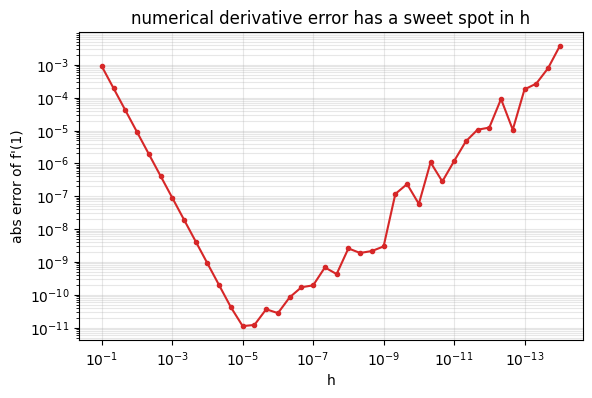

In [15]:
# Error of the central difference vs h: truncation (~h^2) down, round-off (~1/h) up.
hs = np.logspace(-1, -14, 40)
errs = [abs(calculus.numerical_derivative(np.sin, 1.0, h) - np.cos(1.0)) for h in hs]
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.loglog(hs, errs, "o-", color="#d62728", ms=3)
ax.set_xlabel("h")
ax.set_ylabel("abs error of f'(1)")
ax.invert_xaxis()
ax.grid(alpha=0.3, which="both")
ax.set_title("numerical derivative error has a sweet spot in h")
plt.show()

## 10. 微分方程式への接続

ここまでの言葉を一つに束ねます。

- **微分は変化率** — 「いま、どれくらいの速さで変わっているか」
- **積分は蓄積** — 「変化を足し合わせると、量はどうなるか」
- **偏微分は特定方向の変化率**、**勾配は最も増える方向**、**二階微分は曲がり方**

**微分方程式とは、変化率そのものをルールとして与える方程式** です。
未知関数の値そのものではなく、その **変化のしかた** を式で指定し、初期条件から将来を組み立てます。

**ODE(常微分方程式)** は、時間方向の変化を記述します。

$$
\frac{dy}{dt} = f(t, y)
$$

右辺 $f$ が各点で「次にどちらへどれだけ動くか」を決める **傾きの場(方向場)** を作り、
解はその場に沿って流れる曲線になります。下はロジスティック方程式 $dy/dt = r\,y(1 - y/K)$ の方向場と、
いくつかの初期値から出発した解です。**いずれも $y = K$ へ収束** していくのが「変化率がルール」の意味です。

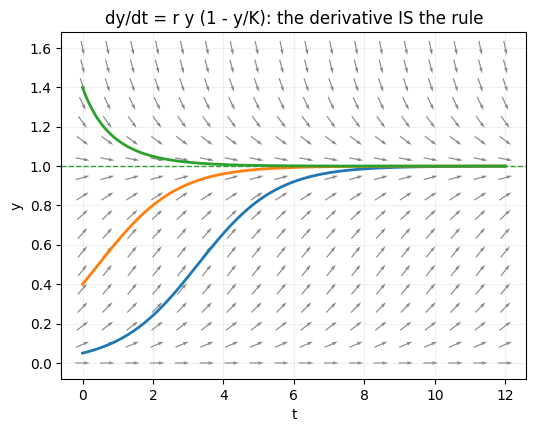

In [16]:
from ode_book import systems, solvers, plotting

# A first-order ODE as a slope field; solutions flow along it toward y = K.
f = systems.logistic(r=0.9, K=1.0)
ax = plotting.direction_field(f, (0, 12), (0, 1.6), n=18)
t = np.linspace(0, 12, 200)
for y0 in (0.05, 0.4, 1.4):
    Y = solvers.rk4(f, [y0], t)
    ax.plot(t, Y[:, 0], lw=2)
ax.axhline(1.0, color="#2ca02c", ls="--", lw=1)
ax.set_title("dy/dt = r y (1 - y/K): the derivative IS the rule")
plt.show()

## Exercises

1. **割線→接線**: $f(x) = x^2$ について、$x_0 = 2$ での差の商を $h = 1, 0.5, 0.1, 0.01$ で計算し、
   $f'(2) = 4$ に近づくことを数値で確かめよ。
2. **Riemann 和の規則**: $\int_0^1 x^2\,dx = 1/3$ を、left / right / midpoint の 3 規則で $n=10, 100$ について比較し、
   どれが速く収束するか観察せよ。
3. **FTC**: $f(x) = e^{-x}$ の累積積分 $F(x) = \int_0^x f$ を数値計算し、$F(x) = 1 - e^{-x}$ と一致することを示せ。
4. **勾配**: $f(x,y) = \sin x \cos y$ の $(\pi/4, \pi/4)$ での勾配を数値で求め、手計算と一致させよ。
5. **Taylor**: $\ln(1+x)$ の 0 まわりの Taylor 展開を SymPy で 5 次まで求め、$x=0.5$ での近似誤差を評価せよ。

## Advanced Notes

- **極限の厳密化 ($\varepsilon$–$\delta$)**: 「近づく」を厳密にするのが $\varepsilon$–$\delta$ 論法です。
  $\lim_{x\to a} f(x) = L$ とは、任意の $\varepsilon>0$ に対しある $\delta>0$ が存在し、
  $0<|x-a|<\delta \Rightarrow |f(x)-L|<\varepsilon$ となること。本書では直感を優先し、厳密版はここに分離します。
- **平均値の定理 (MVT)**: $f$ が $[a,b]$ で連続・$(a,b)$ で微分可能なら、ある $c$ で
  $f'(c) = \dfrac{f(b)-f(a)}{b-a}$。数値解法の誤差評価の土台になります。
- **偏微分の順序交換 (Clairaut)**: 二階偏微分が連続なら $\partial_{xy} f = \partial_{yx} f$。
  これが Hessian の対称性の根拠です。
- **Fubini の定理**: 良い条件下で二重積分は逐次積分に分解できる(`dblquad` が内部でしていること)。
- **微分方程式への伏線**: 「右辺 $f(t,y)$ がほどよく滑らか(Lipschitz 連続)なら、解が一意に存在する」
  という存在・一意性定理が、次章以降の数値解法・相図の前提になります。